In [ ]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="MedOtter/brats2023-gli-dataset",
    repo_type="dataset",
    local_dir="/content/drive/MyDrive/BraTS2023",
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching ... files: 0it [00:00, ?it/s]

'/content/drive/MyDrive/BraTS2023'

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


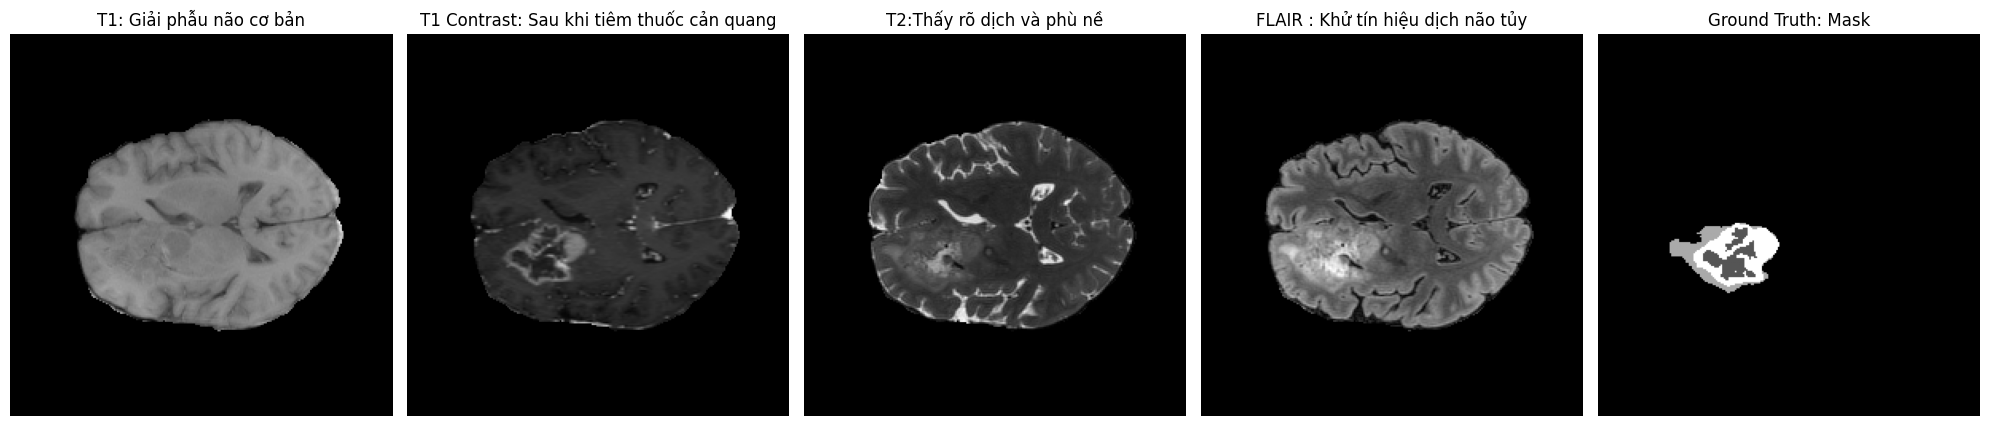

In [15]:
import os
import nibabel as nib
import matplotlib.pyplot as plt

case_dir = r"/content/drive/MyDrive/BraTS2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00000-000"

t1n = nib.load(os.path.join(case_dir, "BraTS-GLI-00000-000-t1n.nii.gz")).get_fdata()
t1c = nib.load(os.path.join(case_dir, "BraTS-GLI-00000-000-t1c.nii.gz")).get_fdata()
t2w = nib.load(os.path.join(case_dir, "BraTS-GLI-00000-000-t2w.nii.gz")).get_fdata()
t2f = nib.load(os.path.join(case_dir, "BraTS-GLI-00000-000-t2f.nii.gz")).get_fdata()
mask = nib.load(os.path.join(case_dir, "BraTS-GLI-00000-000-seg.nii.gz")).get_fdata()

slice_idx = t1n.shape[2] // 2

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

titles = ["T1: Giải phẫu não cơ bản", "T1 Contrast: Sau khi tiêm thuốc cản quang", "T2:Thấy rõ dịch và phù nề", "FLAIR : Khử tín hiệu dịch não tủy", "Ground Truth: Mask"]

images = [t1n, t1c, t2w, t2f, mask]

for ax, img, title in zip(axes, images, titles):
    cmap = "gray" if title != "Ground Truth" else "jet"
    ax.imshow(img[:, :, slice_idx], cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

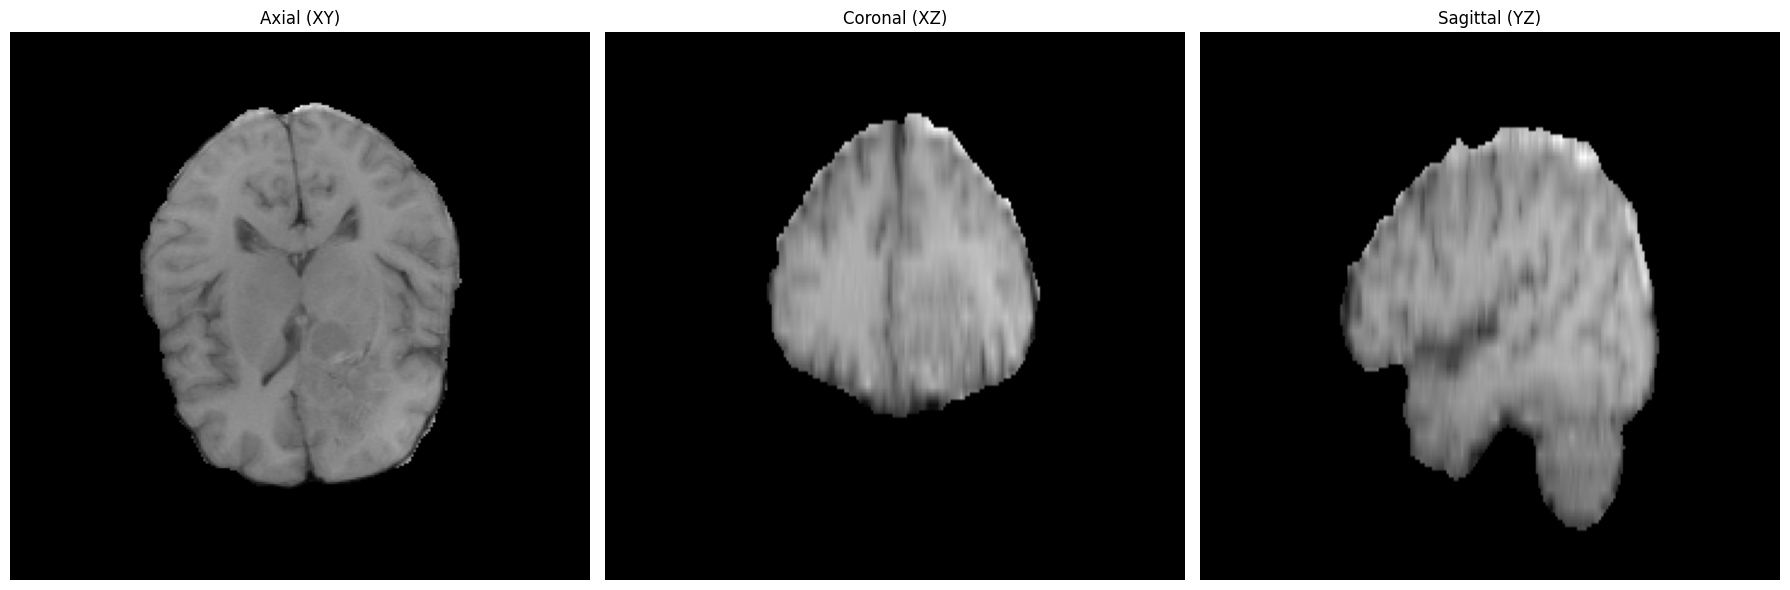

Kích thước mask: (240, 240, 155), số voxel khối u: 57305


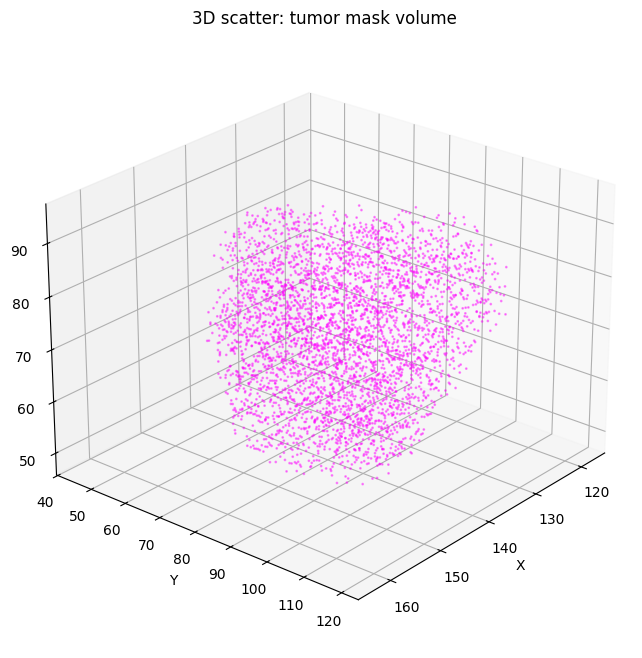

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Hiển thị 3 mặt phẳng chính trong không gian 3D của volume T1
axial = t1n[:, :, slice_idx]
coronal = t1n[:, slice_idx, :]
sagittal = t1n[slice_idx, :, :]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, img, title in zip(
    axes,
    [axial, coronal, sagittal],
    ["Axial (XY)", "Coronal (XZ)", "Sagittal (YZ)"]
):
    ax.imshow(np.rot90(img), cmap='gray', aspect='auto')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 3D scatter đơn giản cho mask khối u
mask_coords = np.column_stack(np.nonzero(mask > 0))
print(f"Kích thước mask: {mask.shape}, số voxel khối u: {len(mask_coords)}")
if len(mask_coords) > 0:
    sample_idx = np.linspace(0, len(mask_coords) - 1, min(4000, len(mask_coords)), dtype=int)
    sample_coords = mask_coords[sample_idx]

    fig = plt.figure(figsize=(8, 8))
    ax3d = fig.add_subplot(111, projection='3d')
    ax3d.scatter(
        sample_coords[:, 0],
        sample_coords[:, 1],
        sample_coords[:, 2],
        c='magenta',
        s=1,
        alpha=0.4,
    )
    ax3d.set_title('3D scatter: tumor mask volume')
    ax3d.set_xlabel('X')
    ax3d.set_ylabel('Y')
    ax3d.set_zlabel('Z')
    ax3d.view_init(elev=25, azim=40)
    plt.show()
else:
    print('Không có voxel khối u (>0) trong mask để hiển thị.')

## Bước 3 – Khám phá dữ liệu BraTS

Trong bước này, chúng ta sẽ xem cấu trúc dataset, các file có trong mỗi case, và các thông tin quan trọng của dữ liệu MRI và mask.

In [17]:
from pathlib import Path
import nibabel as nib
import numpy as np


def resolve_dataset_root():
    candidates = [
        Path("/content/drive/MyDrive/BraTS2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"),
        Path.cwd() / "Datasets" / "brats2023-gli-dataset" / "ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData",
        Path.cwd().parent / "Datasets" / "brats2023-gli-dataset" / "ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData",
        Path("D:/SIC_Capstone 2026/Datasets/brats2023-gli-dataset/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"),
        Path("d:/SIC_Capstone 2026/Datasets/brats2023-gli-dataset/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"),
    ]
    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError("Không tìm thấy thư mục dataset BraTS. Hãy kiểm tra đường dẫn hoặc mount Google Drive.")

base_dir = resolve_dataset_root()
case_dirs = sorted([p for p in base_dir.iterdir() if p.is_dir()])

print(f"Tổng số case trong dataset: {len(case_dirs)}")
print("Danh sách 10 case đầu tiên:")
for p in case_dirs[:10]:
    print("-", p.name)

Tổng số case trong dataset: 1251
Danh sách 10 case đầu tiên:
- BraTS-GLI-00000-000
- BraTS-GLI-00002-000
- BraTS-GLI-00003-000
- BraTS-GLI-00005-000
- BraTS-GLI-00006-000
- BraTS-GLI-00008-000
- BraTS-GLI-00008-001
- BraTS-GLI-00009-000
- BraTS-GLI-00009-001
- BraTS-GLI-00011-000


In [18]:
def describe_case(case_dir):
    files = sorted(case_dir.glob("*.nii.gz"))
    print(f"\nCase: {case_dir.name}")
    print(f"Số file NIfTI tìm thấy: {len(files)}")

    for f in files:
        img = nib.load(f)
        data = img.get_fdata()

        print(f"\n[{f.name}]")
        print("  shape:", data.shape)
        print("  dtype:", data.dtype)
        print("  spacing (voxel size):", img.header.get_zooms()[:3])
        print("  min/max/mean/std:", f"{data.min():.3f}/{data.max():.3f}/{data.mean():.3f}/{data.std():.3f}")

        if "seg" in f.name:
            labels = np.unique(data)
            tumor_voxels = np.count_nonzero(data > 0)
            print("  labels trong mask:", labels)
            print("  số voxel khối u (>0):", tumor_voxels)
        else:
            print("  số voxel khác 0:", np.count_nonzero(data))

sample_case = case_dirs[0]
describe_case(sample_case)


Case: BraTS-GLI-00000-000
Số file NIfTI tìm thấy: 5

[BraTS-GLI-00000-000-seg.nii.gz]
  shape: (240, 240, 155)
  dtype: float64
  spacing (voxel size): (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  min/max/mean/std: 0.000/3.000/0.015/0.200
  labels trong mask: [0. 1. 2. 3.]
  số voxel khối u (>0): 57305

[BraTS-GLI-00000-000-t1c.nii.gz]
  shape: (240, 240, 155)
  dtype: float64
  spacing (voxel size): (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  min/max/mean/std: 0.000/12343.000/345.506/846.790
  số voxel khác 0: 1480170

[BraTS-GLI-00000-000-t1n.nii.gz]
  shape: (240, 240, 155)
  dtype: float64
  spacing (voxel size): (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  min/max/mean/std: 0.000/2023.000/132.998/306.417
  số voxel khác 0: 1480170

[BraTS-GLI-00000-000-t2f.nii.gz]
  shape: (240, 240, 155)
  dtype: float64
  spacing (voxel size): (np.float32(1.0), np.float32(1.0), np.float32(1.0))
  min/max/mean/std: 0.000/2934.000/163.658/394.949
  số voxel khác 0: 148

Hiển thị slice index: 100 (t1n.shape = (240, 240, 155))


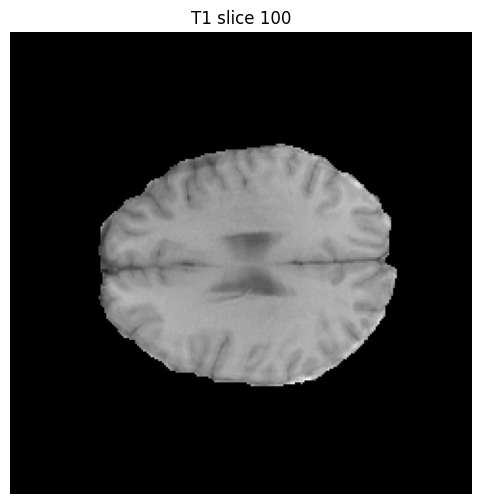

In [20]:
import matplotlib.pyplot as plt

sample_slice = 100

print(f"Hiển thị slice index: {sample_slice} (t1n.shape = {t1n.shape})")

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(t1n[:, :, sample_slice], cmap='gray')
ax.set_title(f"T1 slice {sample_slice}")
ax.axis('off')
plt.show()

Hiển thị slice index: 120 (t1n.shape = (240, 240, 155))


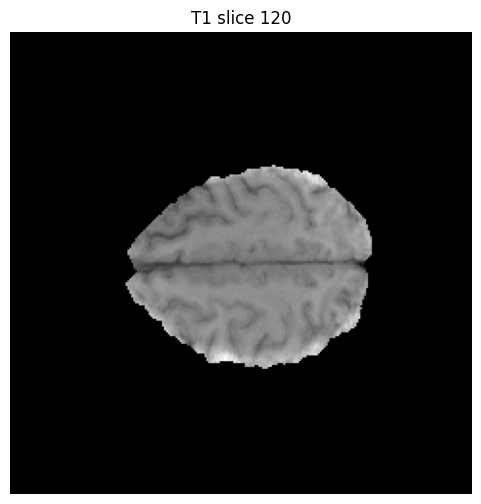

In [23]:
import matplotlib.pyplot as plt

sample_slice = 120

print(f"Hiển thị slice index: {sample_slice} (t1n.shape = {t1n.shape})")

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(t1n[:, :, sample_slice], cmap='gray')
ax.set_title(f"T1 slice {sample_slice}")
ax.axis('off')
plt.show()

### Ý nghĩa của các thông số trên

- `shape`: kích thước của volume 3D, cho biết ảnh có bao nhiêu slice và mỗi slice có kích thước bao nhiêu.
- `dtype`: kiểu dữ liệu số, thường là float32 hoặc int16.
- `spacing`: khoảng cách giữa các voxel theo từng trục, quan trọng khi tính thể tích.
- `min/max/mean/std`: cho thấy phân bố giá trị voxel, giúp kiểm tra chuẩn hóa dữ liệu.
- `mask labels`: cho biết các lớp phân đoạn có trong ground truth, ví dụ 0 = nền, 1/2/4 = các vùng khối u khác nhau.